# Hotel Dataset — 30 Data Cleaning Questions

In [2]:
import pandas as pd

df=pd.read_csv("C:\\Users\\Dell\\Downloads\\Hotel_booking_dataset.csv")
df

,Booking ID,Customer Name,Booking Date,City,Room Type,Booking Channel,Customer Segment,Gender,Age,Room Nights,...,Rating,Guests,Is Member,Cancelled,Payment Method,Gross Amount,Discount Amount,Final Amount,Hotel Cost,Profit
0,BKG01888,Customer_1888,2025-05-17 00:00:00,Mumbai,Suite,Online,Premium,Male,39,4,...,1.4,2,1,0,Credit Card,31674.48,2096.850576,29577.629424,16901.386253,12676.243171
1,BKG00789,Customer_0789,2025-07-29 00:00:00,Bengaluru,Suite,Walk-in,Corporate,Male,25,1,...,2.5,2,1,0,Credit Card,4822.39,735.414475,4086.975525,2746.904163,1340.071362
2,BKG00757,Customer_0757,2025-10-19 00:00:00,Pune,Suite,Corporate,Corporate,Other,50,4,...,1.2,1,0,1,Credit Card,66334.52,15575.345296,50759.174704,40212.657465,10546.517239
3,BKG01079,Customer_1079,2025-12-14 00:00:00,Mumbai,Deluxe,Walk-in,Regular,Male,53,3,...,2.6,6,0,0,Debit Card,19255.92,5328.113064,13927.806936,9639.061764,4288.745172
4,BKG00218,Customer_0218,2025-01-20 00:00:00,Delhi,Suite,Travel Agent,Budget,Male,38,NaN,...,4.2,4,1,0,Cash,15685.38,5160.490020,10524.889980,6545.581304,3979.308676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,BKG01738,Customer_1738,2025-11-27 00:00:00,Hyderabad,Deluxe,Online,Premium,Other,52,3,...,4.0,4,1,0,Net Banking,12777.78,204.444480,12573.335520,9277.794053,3295.541467
2021,BKG01193,Customer_1193,2025-10-22 00:00:00,Hyderabad,Deluxe,Online,Premium,Male,33,5,...,4.7,5,1,1,Net Banking,51298.55,17574.883230,33723.666770,22307.978333,11415.688437
2022,BKG01210,Customer_1210,2025-07-11 00:00:00,Mumbai,Deluxe,Online,Premium,Male,48,6,...,1.3,6,1,0,Debit Card,79546.56,23108.275680,56438.284320,36544.131723,19894.152597
2023,BKG01060,Customer_1060,2025-01-24 00:00:00,Hyderabad,Executive,Travel Agent,Budget,Female,52,2,...,3.8,2,1,1,Debit Card,18041.10,5910.264360,12130.835640,9683.417958,2447.417682


In [4]:
#1. Remove leading/trailing spaces from column names
#Explanation: Column names like "Booking ID " and "Customer Name" have extra spaces. This
#causes errors when you try to select columns. Just strip the spaces so names become clean
#(Booking ID, Customer Name).

df.columns = df.columns.str.strip()
df

,Booking ID,Customer Name,Booking Date,City,Room Type,Booking Channel,Customer Segment,Gender,Age,Room Nights,...,Rating,Guests,Is Member,Cancelled,Payment Method,Gross Amount,Discount Amount,Final Amount,Hotel Cost,Profit
0,BKG01888,Customer_1888,2025-05-17 00:00:00,Mumbai,Suite,Online,Premium,Male,39,4,...,1.4,2,1,0,Credit Card,31674.48,2096.850576,29577.629424,16901.386253,12676.243171
1,BKG00789,Customer_0789,2025-07-29 00:00:00,Bengaluru,Suite,Walk-in,Corporate,Male,25,1,...,2.5,2,1,0,Credit Card,4822.39,735.414475,4086.975525,2746.904163,1340.071362
2,BKG00757,Customer_0757,2025-10-19 00:00:00,Pune,Suite,Corporate,Corporate,Other,50,4,...,1.2,1,0,1,Credit Card,66334.52,15575.345296,50759.174704,40212.657465,10546.517239
3,BKG01079,Customer_1079,2025-12-14 00:00:00,Mumbai,Deluxe,Walk-in,Regular,Male,53,3,...,2.6,6,0,0,Debit Card,19255.92,5328.113064,13927.806936,9639.061764,4288.745172
4,BKG00218,Customer_0218,2025-01-20 00:00:00,Delhi,Suite,Travel Agent,Budget,Male,38,NaN,...,4.2,4,1,0,Cash,15685.38,5160.490020,10524.889980,6545.581304,3979.308676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,BKG01738,Customer_1738,2025-11-27 00:00:00,Hyderabad,Deluxe,Online,Premium,Other,52,3,...,4.0,4,1,0,Net Banking,12777.78,204.444480,12573.335520,9277.794053,3295.541467
2021,BKG01193,Customer_1193,2025-10-22 00:00:00,Hyderabad,Deluxe,Online,Premium,Male,33,5,...,4.7,5,1,1,Net Banking,51298.55,17574.883230,33723.666770,22307.978333,11415.688437
2022,BKG01210,Customer_1210,2025-07-11 00:00:00,Mumbai,Deluxe,Online,Premium,Male,48,6,...,1.3,6,1,0,Debit Card,79546.56,23108.275680,56438.284320,36544.131723,19894.152597
2023,BKG01060,Customer_1060,2025-01-24 00:00:00,Hyderabad,Executive,Travel Agent,Budget,Female,52,2,...,3.8,2,1,1,Debit Card,18041.10,5910.264360,12130.835640,9683.417958,2447.417682


In [8]:
#2.Standardize all date formats into one consistent format (YYYY-MM-DD)
#Explanation: Dates appear as 2025-05-17 00:00:00, 2025/02/20, 15/01/2025, and even
#invalid ones like 32/13/2025. Convert everything to a single clean format and turn bad dates
#into missing values.

df['Booking Date'] = pd.to_datetime(
    df['Booking Date'],
    errors='coerce',
    format='mixed',
    dayfirst=True
)

df['Booking Date'] = df['Booking Date'].dt.strftime('%Y-%m-%d')

df['Booking Date']

0       2025-05-17
1       2025-07-29
2       2025-10-19
3       2025-12-14
4       2025-01-20
           ...    
2020    2025-11-27
2021    2025-10-22
2022    2025-07-11
2023    2025-01-24
2024    2025-04-06
Name: Booking Date, Length: 2025, dtype: object

In [9]:
#3.Handle completely missing Customer Name values
#Explanation: Some rows have blank Customer Name or values like N/A. Decide whether to
#fill them with a placeholder (e.g., “Unknown”) or drop those rows, depending on whether
#the name is critical for analysis.

# Replace N/A and blank values with NaN
df['Customer Name'] = df['Customer Name'].replace(
    ['N/A', 'NA', 'n/a', 'na', ''],
    pd.NA
)

# Remove extra spaces
df['Customer Name'] = df['Customer Name'].str.strip()

# Fill missing names with Unknown
df['Customer Name'] = df['Customer Name'].fillna('Unknown')

print(df['Customer Name'])    

0       Customer_1888
1       Customer_0789
2       Customer_0757
3       Customer_1079
4       Customer_0218
            ...      
2020    Customer_1738
2021    Customer_1193
2022    Customer_1210
2023    Customer_1060
2024    Customer_0642
Name: Customer Name, Length: 2025, dtype: object


In [10]:
#check the missing values
df['Customer Name'].isna().sum()

np.int64(0)

In [11]:
#4.Fix inconsistent Gender values
#Explanation: Gender appears as Male, FEMALE, male, F, M, Other, etc. Convert everything to
#a standard set such as Male, Female, Other.

# Remove extra spaces and convert to lowercase
df['Gender'] = df['Gender'].str.strip().str.lower()

# Standardize gender values
df['Gender'] = df['Gender'].replace({
    'm': 'Male',
    'male': 'Male',
    'f': 'Female',
    'female': 'Female',
    'other': 'Other'
})

# Any remaining unexpected values can be treated as Other
df.loc[~df['Gender'].isin(['Male', 'Female', 'Other']), 'Gender'] = 'Other'

print(df['Gender'].value_counts())    

Gender
Female    1004
Male       952
Other       69
Name: count, dtype: int64


In [12]:
#5.Clean and standardize City names
#Explanation: Cities have typos and casing issues (mumbai, Mumbai , Bangalore, Hydrabad,
#blank). Correct spelling, remove extra spaces, and make casing consistent (e.g., Title Case).

# Remove extra spaces
df['City'] = df['City'].str.strip()

# Convert blank values to missing
df['City'] = df['City'].replace(['', 'N/A', 'NA', 'na'], pd.NA)

# Fix spelling mistakes
df['City'] = df['City'].replace({
    'Hydrabad': 'Hyderabad',
    'Bangalor': 'Bangalore',
    'Mumabi': 'Mumbai'
})

# Convert city names to Title Case
df['City'] = df['City'].str.title()

# Fill missing city names
df['City'] = df['City'].fillna('Unknown')

print(df['City'].value_counts())

City
Delhi        363
Mumbai       358
Pune         335
Bengaluru    317
Chennai      309
Hyderabad    307
Unknown       29
Bangalore      7
Name: count, dtype: int64


In [14]:
#6.Standardize Room Type categories
#Explanation: Room Type has Suite, Deluxe, delux, standard, exec, Unknown, and blanks.
#Map similar values to a clean list: Standard, Deluxe, Suite, Executive.

# Remove extra spaces and convert to lowercase
df['Room Type'] = df['Room Type'].str.strip().str.lower()

# Standardize room type values
df['Room Type'] = df['Room Type'].replace({
    'standard': 'Standard',
    'deluxe': 'Deluxe',
    'delux': 'Deluxe',
    'suite': 'Suite',
    'exec': 'Executive',
    'executive': 'Executive'
})

# Convert unknown or blank values to missing
df['Room Type'] = df['Room Type'].replace(
    ['unknown', '', 'n/a', 'na'],
    pd.NA
)

df['Room Type'].value_counts(dropna=False)

Room Type
Deluxe       548
Executive    506
Suite        479
Standard     454
NaN           31
<NA>           7
Name: count, dtype: int64

In [15]:
#7.Clean Booking Channel values
#Explanation: Values include Online, online, Walk-in, Travel Agent, TravelAgent, corp,
#Corporate. Unify them into a small consistent set (Online, Walk-in, Corporate, Travel Agent).

# Remove extra spaces and convert to lowercase
df['Booking Channel'] = df['Booking Channel'].str.strip().str.lower()

# Standardize booking channel values
df['Booking Channel'] = df['Booking Channel'].replace({
    'online': 'Online',
    'walk-in': 'Walk-in',
    'walkin': 'Walk-in',
    'travel agent': 'Travel Agent',
    'travelagent': 'Travel Agent',
    'corp': 'Corporate',
    'corporate': 'Corporate'
})

print(df['Booking Channel'].value_counts())

Booking Channel
Online          555
Walk-in         531
Travel Agent    472
Corporate       467
Name: count, dtype: int64


In [17]:
#8.Standardize Customer Segment
#Explanation: Segments appear as Premium, regular, REG, Budget , VIP, etc. Create a clean set
#such as Budget, Regular, Premium, Corporate, VIP and map everything to it.

df['Customer Segment'] = df['Customer Segment'].replace({
    'Premium': 'Premium',
    'premium': 'Premium',
    'VIP': 'VIP',
    'vip': 'VIP',
    'regular': 'Regular',
    'Regular': 'Regular',
    'REG': 'Regular',
    'Budget': 'Budget',
    'budget': 'Budget',
    'Corporate': 'Corporate',
    'corporate': 'Corporate',
    'Corp': 'Corporate'
})

df['Customer Segment'].value_counts()

Customer Segment
Premium      517
Budget       517
Regular      496
Corporate    480
Budget         8
VIP            5
premium        2
Name: count, dtype: int64

In [19]:
#9.Fix Age column (invalid and non-numeric values)
#Explanation: Age has numbers, blanks, 30 yrs, 25 years, 45Y, and impossible values like 150
#or 100. Extract the number, convert to integer, and set unrealistic ages (e.g., <18 or >100) to
#missing.


import pandas as pd
import numpy as np

#Extract numeric value from Age
df['Age'] = df['Age'].astype(str).str.extract(r'(\d+)')[0]

#Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

#Set unrealistic ages to missing
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

#Convert to nullable integer
df['Age'] = df['Age'].astype('Int64')

df['Age'].head(20)
df['Age'].isna().sum()

np.int64(51)

In [21]:
#10.Clean Room Nights column
#Explanation: Values include numbers, N/A, 3 nights, 100, 30. Extract only the numeric part,
#convert to integer, and decide what to do with extreme values (e.g., 100 nights).


import pandas as pd
import numpy as np

# Extract numeric part
df['Room Nights'] = (
    df['Room Nights']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

# Convert to numeric
df['Room Nights'] = pd.to_numeric(df['Room Nights'], errors='coerce')

# Treat extreme values as missing
df.loc[df['Room Nights'] > 30, 'Room Nights'] = np.nan

# Convert to nullable integer
df['Room Nights'] = df['Room Nights'].astype('Int64')

df['Room Nights'].head(20)
df['Room Nights'].isna().sum()

np.int64(20)

In [23]:
#11.Fix Room Rate (mixed formats and extreme values)
#Explanation: Room Rate contains normal numbers, 15k, $8000, 12000 INR, 100000, 250000,
#and blanks. Convert text formats to numbers, remove currency symbols, and flag or handle
#unrealistic rates.

import pandas as pd
import numpy as np

# Convert to string
df['Room Rate'] = df['Room Rate'].astype(str).str.strip()

# Convert 15k / 15K to 15000
df['Room Rate'] = df['Room Rate'].str.replace(
    r'(\d+(?:\.\d+)?)\s*[kK]',
    lambda x: str(float(x.group(1)) * 1000),
    regex=True
)

# Remove currency symbols and text
df['Room Rate'] = df['Room Rate'].str.replace(
    r'[$₹,]',
    '',
    regex=True
)

df['Room Rate'] = df['Room Rate'].str.replace(
    r'\s*(INR|USD|Rs\.?)\s*',
    '',
    regex=True,
    case=False
)

# Convert to numeric
df['Room Rate'] = pd.to_numeric(
    df['Room Rate'],
    errors='coerce'
)

# Set unrealistic rates to missing
df.loc[df['Room Rate'] > 50000, 'Room Rate'] = np.nan

# Round first, then convert to nullable integer
df['Room Rate'] = df['Room Rate'].round().astype('Int64')

print(df['Room Rate'].head(20))

0      7919
1      4822
2     16584
3      6419
4      5228
5      5654
6     11145
7      9599
8     10984
9      2571
10    16515
11     2703
12    11964
13     2445
14    12005
15     4917
16    13394
17    11406
18    11927
19    10584
Name: Room Rate, dtype: Int64


In [24]:
#12.Clean Discount % column
#Explanation: Discount has numbers, none, 10%, 5 %, N/A, and impossible values like 120.
#Convert everything to a pure number between 0 and 100; treat “none” as 0 and values >100
#as missing or capped.

import pandas as pd
import numpy as np

# Convert to string and remove extra spaces
df['Discount %'] = df['Discount %'].astype(str).str.strip()

# Treat "none" as 0
df.loc[df['Discount %'].str.lower() == 'none', 'Discount %'] = '0'

# Remove % symbol
df['Discount %'] = df['Discount %'].str.replace('%', '', regex=False)

# Convert to numeric
df['Discount %'] = pd.to_numeric(
    df['Discount %'],
    errors='coerce'
)

# Values greater than 100 are unrealistic
df.loc[df['Discount %'] > 100, 'Discount %'] = np.nan

# Convert to nullable integer
df['Discount %'] = df['Discount %'].round().astype('Int64')

print(df['Discount %'].head(20))
print(df['Discount %'].isna().sum())

0      7
1     15
2     23
3     28
4     33
5     31
6     34
7     18
8     16
9     22
10    34
11    34
12    25
13    14
14    15
15    12
16    14
17    19
18    18
19     5
Name: Discount %, dtype: Int64
45


In [25]:
#13. Handle missing and invalid Rating values
#Explanation: Rating has numbers, blanks, 5/5, 4 stars, and values above 5 (e.g., 6, 9).
#Convert to a 1–5 scale and set invalid entries to missing.
import pandas as pd
import numpy as np

# Convert Rating to string
df['Rating'] = df['Rating'].astype(str).str.strip()

# Extract numeric part
df['Rating'] = df['Rating'].str.extract(r'(\d+(?:\.\d+)?)')[0]

# Convert to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Set invalid ratings outside 1–5 to missing
df.loc[(df['Rating'] < 1) | (df['Rating'] > 5), 'Rating'] = np.nan

# Convert to nullable numeric type
df['Rating'] = df['Rating'].astype('Float64')

print(df['Rating'].head(20))
print("Missing/invalid ratings:", df['Rating'].isna().sum())    

0      1.4
1      2.5
2      1.2
3      2.6
4      4.2
5     <NA>
6      3.6
7      2.3
8      4.1
9      4.5
10     4.6
11     2.8
12     4.1
13     2.4
14     4.8
15     2.9
16     2.7
17     4.0
18     1.0
19     4.6
Name: Rating, dtype: Float64
Missing/invalid ratings: 53


In [26]:
#14.Clean Guests column (extreme values)
#Explanation: Most values are reasonable (1–6), but some are 15, 25, or 40. Decide a sensible
#maximum (e.g., 10) and set higher values to missing or investigate them.

import pandas as pd
import numpy as np

# Convert to string
df['Guests'] = df['Guests'].astype(str).str.strip()

# Extract numeric part
df['Guests'] = df['Guests'].str.extract(r'(\d+)')[0]

# Convert to numeric
df['Guests'] = pd.to_numeric(df['Guests'], errors='coerce')

# Set unrealistic values (>10) to missing
df.loc[df['Guests'] > 10, 'Guests'] = np.nan

# Convert to nullable integer
df['Guests'] = df['Guests'].astype('Int64')

print(df['Guests'].head(20))
print("Missing/invalid guests:", df['Guests'].isna().sum())

0     2
1     2
2     1
3     6
4     4
5     2
6     3
7     2
8     4
9     2
10    5
11    2
12    1
13    4
14    4
15    3
16    5
17    2
18    2
19    3
Name: Guests, dtype: Int64
Missing/invalid guests: 15


In [27]:
#15.Standardize Is Member column
#Explanation: Values are mixed: 1, 0, Y, Yes, Member, blanks. Convert everything to a clear
#Yes/No or 1/0 format.

import pandas as pd
import numpy as np

# Clean spaces and convert to lowercase
df['Is Member'] = df['Is Member'].astype(str).str.strip().str.lower()

# Standardize values
df['Is Member'] = df['Is Member'].replace({
    '1': 'Yes',
    'y': 'Yes',
    'yes': 'Yes',
    'member': 'Yes',
    '0': 'No',
    'n': 'No',
    'no': 'No',
    'non-member': 'No',
    'non member': 'No',
    'nan': np.nan,
    '': np.nan
})

print(df['Is Member'].value_counts(dropna=False))

Is Member
No     1024
Yes    1001
Name: count, dtype: int64


In [29]:
#16.Standardize Cancelled column
#Explanation: Cancelled appears as 0, 1, Yes, Y, N. Convert to a consistent 0/1 or Yes/No
#format.

import pandas as pd
import numpy as np

# Clean spaces and convert to lowercase
df['Cancelled'] = df['Cancelled'].astype(str).str.strip().str.lower()

# Standardize values
df['Cancelled'] = df['Cancelled'].replace({
    '1': 1,
    'yes': 1,
    'y': 1,
    '0': 0,
    'no': 0,
    'n': 0,
    'nan': np.nan,
    '': np.nan
})

# Convert to nullable integer
df['Cancelled'] = pd.to_numeric(
    df['Cancelled'],
    errors='coerce'
).astype('Int64')

df['Cancelled'].value_counts(dropna=False)

Cancelled
1       1022
0        994
<NA>       9
Name: count, dtype: Int64

In [30]:
#17.Clean Payment Method values
#Explanation: Payment methods have inconsistent casing and spacing (Credit Card, credit
#card, upi, Net Banking, cash , blanks). Standardize to a clean list (Credit Card, Debit Card, UPI,
#Net Banking, Cash).

import pandas as pd
import numpy as np

# Remove extra spaces and convert to lowercase
df['Payment Method'] = (
    df['Payment Method']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Standardize payment methods
df['Payment Method'] = df['Payment Method'].replace({
    'credit card': 'Credit Card',
    'creditcard': 'Credit Card',
    'cc': 'Credit Card',

    'debit card': 'Debit Card',
    'debitcard': 'Debit Card',
    'dc': 'Debit Card',

    'upi': 'UPI',

    'net banking': 'Net Banking',
    'netbanking': 'Net Banking',

    'cash': 'Cash',

    'nan': np.nan,
    '': np.nan
})

print(df['Payment Method'].value_counts(dropna=False))

Payment Method
Debit Card     420
UPI            412
Credit Card    395
Cash           390
Net Banking    378
NaN             30
Name: count, dtype: int64


In [31]:
#18. Remove or flag duplicate Booking IDs
#Explanation: Some Booking IDs (e.g., BKG00042, BKG01640) appear more than once. Decide
#whether to keep the first occurrence, the most complete row, or mark them for review.

# Find duplicate Booking IDs
duplicates = df[df['Booking ID'].duplicated(keep=False)].sort_values('Booking ID')

# Create a duplicate flag
df['Duplicate_Booking_ID'] = df['Booking ID'].duplicated(keep=False)

# Display duplicate records
print(duplicates[['Booking ID']])

     Booking ID
1879   BKG00034
714    BKG00034
1970   BKG00042
1908   BKG00042
346    BKG00075
1597   BKG00075
1292   BKG00131
1715   BKG00131
176    BKG00172
1623   BKG00172
1127   BKG00204
292    BKG00204
1449   BKG00248
1236   BKG00248
876    BKG00516
938    BKG00516
1381   BKG00567
640    BKG00567
408    BKG00772
863    BKG00772
235    BKG00783
1534   BKG00783
998    BKG00989
1038   BKG00989
1147   BKG01085
1135   BKG01085
842    BKG01111
575    BKG01111
1009   BKG01267
972    BKG01267
901    BKG01314
1560   BKG01314
979    BKG01374
281    BKG01374
1121   BKG01458
356    BKG01458
1182   BKG01622
1491   BKG01622
57     BKG01640
1847   BKG01640
809    BKG01702
751    BKG01702
681    BKG01808
368    BKG01808
745    BKG01863
1662   BKG01863
1872   BKG01913
1340   BKG01913
1476   BKG01966
1114   BKG01966


In [32]:
#19.Handle missing Room Type values
#Explanation: Some rows have blank Room Type. You can either drop those rows, fill with
#“Unknown”, or try to infer from other columns if possible.

import pandas as pd
import numpy as np

# Replace blank values with NaN
df['Room Type'] = df['Room Type'].replace(r'^\s*$', np.nan, regex=True)

# Fill missing values with "Unknown"
df['Room Type'] = df['Room Type'].fillna('Unknown')

print(df['Room Type'].value_counts())

Room Type
Deluxe       548
Executive    506
Suite        479
Standard     454
Unknown       38
Name: count, dtype: int64


In [33]:
#20.Fix inconsistent Final Amount calculations
#Explanation: Final Amount should roughly equal Gross Amount − Discount Amount, but
#some rows have missing Final Amount or clear calculation errors. Recalculate or flag
#inconsistencies.

import pandas as pd
import numpy as np

# Convert columns to numeric
df['Gross Amount'] = pd.to_numeric(df['Gross Amount'], errors='coerce')
df['Discount Amount'] = pd.to_numeric(df['Discount Amount'], errors='coerce')
df['Final Amount'] = pd.to_numeric(df['Final Amount'], errors='coerce')

# Calculate expected Final Amount
df['Expected Final Amount'] = (
    df['Gross Amount'] - df['Discount Amount']
)

# Calculate difference
df['Amount Difference'] = (
    df['Final Amount'] - df['Expected Final Amount']
)

# Flag inconsistent values
df['Final Amount Status'] = np.where(
    df['Final Amount'].isna(),
    'Missing',
    np.where(
        np.isclose(
            df['Final Amount'],
            df['Expected Final Amount'],
            atol=1
        ),
        'Correct',
        'Inconsistent'
    )
)

print(
    df[
        [
            'Gross Amount',
            'Discount Amount',
            'Final Amount',
            'Expected Final Amount',
            'Final Amount Status'
        ]
    ].head(20)
)

    Gross Amount  Discount Amount  Final Amount  Expected Final Amount  \
0       31674.48      2096.850576  29577.629424           29577.629424   
1        4822.39       735.414475   4086.975525            4086.975525   
2       66334.52     15575.345296  50759.174704           50759.174704   
3       19255.92      5328.113064  13927.806936           13927.806936   
4       15685.38      5160.490020  10524.889980           10524.889980   
5       11308.68      3518.130348   7790.549652            7790.549652   
6       22290.58      7663.501404  14627.078596           14627.078596   
7       47993.20      8825.949480  39167.250520           39167.250520   
8       32952.69      5246.068248  27706.621752           27706.621752   
9       10284.96      2287.375104   7997.584896            7997.584896   
10      16514.78      5615.025200  10899.754800           10899.754800   
11       5405.38      1864.856100   3540.523900            3540.523900   
12      59822.05     14788.010760  450

In [34]:
#21.Clean Customer Name (placeholder and invalid names)
#Explanation: Names include Customer_1888, 12345, john doe, N/A, blanks. Decide how to
#treat non-real names (keep as-is, replace with “Unknown”, or drop).

import pandas as pd
import numpy as np

# Clean spaces
df['Customer Name'] = df['Customer Name'].astype(str).str.strip()

# Convert obvious missing values to NaN
df['Customer Name'] = df['Customer Name'].replace(
    ['N/A', 'n/a', 'NA', 'na', 'None', 'none', '', 'nan'],
    np.nan
)

# Identify invalid/placeholder names
invalid_names = (
    df['Customer Name'].str.match(r'^Customer_\d+$', na=False) |
    df['Customer Name'].str.match(r'^\d+$', na=False)
)

# Replace invalid names with Unknown
df.loc[invalid_names, 'Customer Name'] = 'Unknown'

# Fill remaining missing names
df['Customer Name'] = df['Customer Name'].fillna('Unknown')

print(df['Customer Name'].head(20))

0     Unknown
1     Unknown
2     Unknown
3     Unknown
4     Unknown
5     Unknown
6     Unknown
7     Unknown
8     Unknown
9     Unknown
10    Unknown
11    Unknown
12    Unknown
13    Unknown
14    Unknown
15    Unknown
16    Unknown
17    Unknown
18    Unknown
19    Unknown
Name: Customer Name, dtype: object


In [35]:
#22. Convert all numeric columns to proper numeric data types
#Explanation: Many columns that should be numbers are currently stored as text because of
#mixed formats. Convert them to integer or float so calculations work correctly.


import pandas as pd
import numpy as np

# Columns that should contain numeric values
numeric_columns = [
    'Age',
    'Room Nights',
    'Room Rate',
    'Discount %',
    'Rating',
    'Guests',
    'Gross Amount',
    'Discount Amount',
    'Final Amount'
]

# Convert columns to numeric
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert whole-number columns to nullable integers
integer_columns = [
    'Age',
    'Room Nights',
    'Guests'
]

for col in integer_columns:
    df[col] = df[col].round().astype('Int64')

# Display data types
print(df[numeric_columns].dtypes)

Age                  Int64
Room Nights          Int64
Room Rate            Int64
Discount %           Int64
Rating             Float64
Guests               Int64
Gross Amount       float64
Discount Amount    float64
Final Amount       float64
dtype: object


In [36]:
#23.Handle missing values in key financial columns (Gross Amount, Discount Amount, Final
#Amount, Profit)
#Explanation: Some financial columns have blanks. Decide whether to drop those rows, fill
#with 0, or calculate missing values from other columns when possible.

import pandas as pd
import numpy as np

# Convert financial columns to numeric
financial_cols = [
    'Gross Amount',
    'Discount Amount',
    'Final Amount',
    'Profit'
]

for col in financial_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate missing Discount Amount
df.loc[
    df['Discount Amount'].isna() &
    df['Gross Amount'].notna() &
    df['Final Amount'].notna(),
    'Discount Amount'
] = (
    df['Gross Amount'] - df['Final Amount']
)

# Calculate missing Final Amount
df.loc[
    df['Final Amount'].isna() &
    df['Gross Amount'].notna() &
    df['Discount Amount'].notna(),
    'Final Amount'
] = (
    df['Gross Amount'] - df['Discount Amount']
)

# Calculate missing Profit if the dataset has a Cost column
if 'Cost' in df.columns:
    df.loc[
        df['Profit'].isna() &
        df['Final Amount'].notna() &
        df['Cost'].notna(),
        'Profit'
    ] = (
        df['Final Amount'] - df['Cost']
    )

# Check remaining missing values
print(df[financial_cols].isna().sum())

Gross Amount       0
Discount Amount    0
Final Amount       0
Profit             0
dtype: int64


In [37]:
#24.Remove rows with completely invalid dates
#Explanation: Dates like 32/13/2025 are impossible. Identify and either remove those rows or
#set the date to missing.

import pandas as pd

# Convert date column to datetime
df['Booking Date'] = pd.to_datetime(
    df['Booking Date'],
    errors='coerce',
    dayfirst=True
)

# Check invalid/missing dates
print("Invalid dates:", df['Booking Date'].isna().sum())

# Display rows with invalid dates
print(df[df['Booking Date'].isna()])

Invalid dates: 30
     Booking ID Customer Name Booking Date       City  Room Type  \
6      BKG00282       Unknown          NaT  Bengaluru      Suite   
26     BKG00310       Unknown          NaT      Delhi      Suite   
156    BKG01655       Unknown          NaT  Hyderabad   Standard   
241    BKG00793       Unknown          NaT  Hyderabad     Deluxe   
245    BKG01539       Unknown          NaT    Chennai     Deluxe   
248    BKG01384       Unknown          NaT     Mumbai      Suite   
286    BKG01436       Unknown          NaT  Bengaluru   Standard   
299    BKG00351       Unknown          NaT  Hyderabad  Executive   
326    BKG00781       Unknown          NaT     Mumbai   Standard   
431    BKG01580       Unknown          NaT  Hyderabad     Deluxe   
569    BKG00993       Unknown          NaT  Hyderabad      Suite   
588    BKG01576       Unknown          NaT  Bengaluru     Deluxe   
732    BKG01557       Unknown          NaT       Pune      Suite   
760    BKG00960       Unknown 

C:\Users\Dell\AppData\Local\Temp\ipykernel_2236\1633455191.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Booking Date'] = pd.to_datetime(


In [39]:
#25.Standardize boolean-like columns (Is Member and Cancelled) to the same format
#Explanation: Keeping both columns in the same style (both 0/1 or both Yes/No) makes
#filtering and analysis much easier and less error-prone.


import pandas as pd
import numpy as np

# Standardize Is Member
member_map = {
    'yes': 1,
    'y': 1,
    'member': 1,
    '1': 1,
    'no': 0,
    'n': 0,
    '0': 0
}

df['Is Member'] = (
    df['Is Member']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(member_map)
    .astype('Int64')
)

# Standardize Cancelled
cancelled_map = {
    'yes': 1,
    'y': 1,
    '1': 1,
    'no': 0,
    'n': 0,
    '0': 0
}

df['Cancelled'] = (
    df['Cancelled']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(cancelled_map)
    .astype('Int64')
)

# Check results
print(df[['Is Member', 'Cancelled']].head(20))
print(df[['Is Member', 'Cancelled']].dtypes)

    Is Member  Cancelled
0           1          0
1           1          0
2           0          1
3           0          0
4           1          0
5           0          1
6           1          1
7           0          1
8           1          0
9           0          1
10          0          1
11          1          0
12          0          1
13          1          0
14          0          0
15          0          0
16          1          1
17          0          0
18          0          1
19          0          0
Is Member    Int64
Cancelled    Int64
dtype: object


In [40]:
#26.Trim extra spaces from all text columns
#Explanation: Many text fields have leading/trailing spaces (e.g., "Budget ", "Mumbai ").
#Removing them prevents “Budget” and “Budget ” from being treated as different categories.

# Select all text columns
text_columns = df.select_dtypes(include='object').columns

# Remove leading and trailing spaces
for col in text_columns:
    df[col] = df[col].str.strip()

print("Extra spaces removed from all text columns.")

Extra spaces removed from all text columns.


In [41]:
#27.Fix extreme or impossible Age values
#Explanation: Ages such as 150, 120, or 100 are unrealistic for hotel customers. Set a
#reasonable range (e.g., 18–90) and replace values outside it with missing.

import pandas as pd
import numpy as np

# Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Replace unrealistic ages with missing
df.loc[
    (df['Age'] < 18) | (df['Age'] > 90),
    'Age'
] = np.nan

# Convert to nullable integer
df['Age'] = df['Age'].astype('Int64')

# Check result
print(df['Age'].head(20))
print("Invalid/missing ages:", df['Age'].isna().sum())

0       39
1       25
2       50
3       53
4       38
5       35
6       50
7       33
8       65
9       48
10      47
11      52
12      44
13    <NA>
14      29
15      49
16      53
17      34
18      58
19      42
Name: Age, dtype: Int64
Invalid/missing ages: 56


In [43]:
#28.Handle missing Gender values
#Explanation: Some rows have blank Gender. You can fill with “Unknown”, drop the rows, or
#leave them as missing depending on your analysis needs.

import pandas as pd
import numpy as np

#Remove extra spaces
df['Gender'] = df['Gender'].astype(str).str.strip()

#Convert blank and common missing values to NaN
df['Gender'] = df['Gender'].replace(
    ['nan', 'NaN', 'N/A', 'n/a', 'NA', ''],
    np.nan
)

#Fill missing values with Unknown
df['Gender'] = df['Gender'].fillna('Unknown')

#Check results
df['Gender'].value_counts()

Gender
Female    1004
Male       952
Other       69
Name: count, dtype: int64

In [44]:
#29.Correct obvious typos in categorical columns
#Explanation: Examples include delux → Deluxe, exec → Executive, Hydrabad → Hyderabad,
#Bangalore → Bengaluru. Fixing these improves grouping and reporting accuracy.

# Correct Room Type typos
df['Room Type'] = df['Room Type'].replace({
    'delux': 'Deluxe',
    'Delux': 'Deluxe',
    'exec': 'Executive',
    'Exec': 'Executive'
})

# Correct City typos
df['City'] = df['City'].replace({
    'Hydrabad': 'Hyderabad',
    'hydrabad': 'Hyderabad',
    'Bangalore': 'Bengaluru',
    'bangalore': 'Bengaluru'
})

# Check unique values
print("Room Types:")
print(df['Room Type'].unique())

print("\nCities:")
print(df['City'].unique())

Room Types:
['Suite' 'Deluxe' 'Standard' 'Executive' 'Unknown']

Cities:
['Mumbai' 'Bengaluru' 'Pune' 'Delhi' 'Chennai' 'Hyderabad' 'Unknown']


In [46]:
#30.Decide how to treat rows with too many missing values
#Explanation: Some rows are missing Customer Name, City, Room Type, Age, and other
#important fields at the same time. Decide a threshold (e.g., more than 40% missing) and
#drop or flag those incomplete rows.

# Calculate percentage of missing values in each row
df['Missing_Percentage'] = df.isna().mean(axis=1) * 100

# Flag rows with more than 40% missing values
df['Incomplete_Row'] = df['Missing_Percentage'] > 40

# Check how many incomplete rows exist
print("Incomplete rows:", df['Incomplete_Row'].sum())

# Display incomplete rows
df[df['Incomplete_Row']]

Incomplete rows: 0


,Booking ID,Customer Name,Booking Date,City,Room Type,Booking Channel,Customer Segment,Gender,Age,Room Nights,...,Final Amount,Hotel Cost,Profit,Room Rate_Flag,Duplicate_Booking_ID,Expected Final Amount,Amount Difference,Final Amount Status,Missing_Percentage,Incomplete_Row


# Matplotlib + Seaborn questions based on the hotel booking dataset

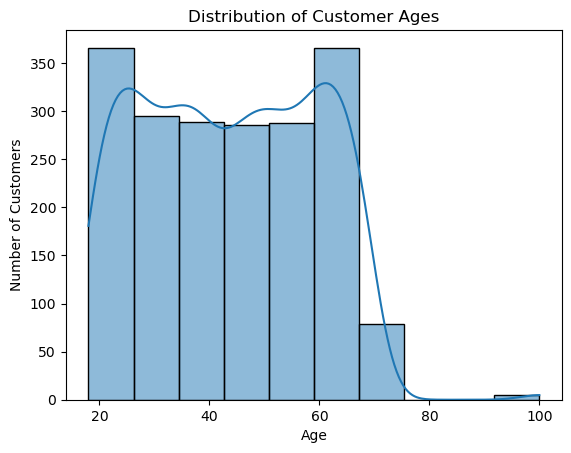

In [4]:
#1.Histogram of Age
#What to plot: Distribution of customer ages
#Columns: Age
#Required: Age should be numeric and cleaned (remove text like “30 yrs”, impossible values)
#Easy explanation: Shows how many customers fall in different age groups (young, middle-
#aged, old).

import pandas as pd
df=pd.read_csv("C:\\Users\\Dell\\Downloads\\Hotel_booking_dataset.csv")

# Convert Age to numeric
df['Age'] = df['Age'].astype(str).str.extract(r'(\d+)')[0]
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Remove impossible ages
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = pd.NA

# Plot histogram
sns.histplot(data=df, x='Age', bins=10, kde=True)

plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

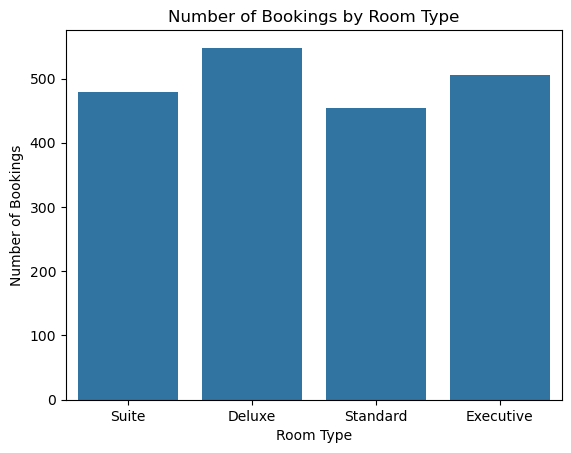

In [5]:
#2.Count Plot of Room Type
#What to plot: Number of bookings for each room type
#Columns: Room Type
#Required: Room Type cleaned and standardized (Deluxe, Suite, Standard, Executive)
#Easy explanation: Quickly tells which room type is booked the most.


import seaborn as sns
import matplotlib.pyplot as plt

# Standardize Room Type values
df['Room Type'] = df['Room Type'].astype(str).str.strip().str.lower()

df['Room Type'] = df['Room Type'].replace({
    'delux': 'Deluxe',
    'deluxe': 'Deluxe',
    'suite': 'Suite',
    'standard': 'Standard',
    'exec': 'Executive',
    'executive': 'Executive'
})

# Keep only required categories
valid_rooms = ['Deluxe', 'Suite', 'Standard', 'Executive']
df = df[df['Room Type'].isin(valid_rooms)]

# Count plot
sns.countplot(data=df, x='Room Type')

plt.title('Number of Bookings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Bookings')
plt.show()

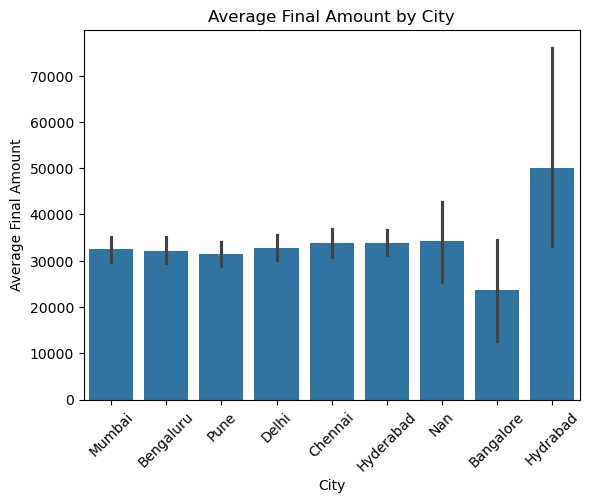

In [6]:
#3.Bar Plot of Average Final Amount by City
#What to plot: Average spending (Final Amount) in each city
#Columns: City, Final Amount
#Required: City cleaned, Final Amount numeric
#Easy explanation: Shows which city generates higher average revenue.


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean City
df['City'] = df['City'].astype(str).str.strip().str.title()

# Convert Final Amount to numeric
df['Final Amount'] = pd.to_numeric(df['Final Amount'], errors='coerce')

# Remove rows where City or Final Amount is missing
plot_df = df.dropna(subset=['City', 'Final Amount'])

# Bar plot of average Final Amount by City
sns.barplot(
    data=plot_df,
    x='City',
    y='Final Amount',
    estimator='mean'
)

plt.title('Average Final Amount by City')
plt.xlabel('City')
plt.ylabel('Average Final Amount')
plt.xticks(rotation=45)
plt.show()

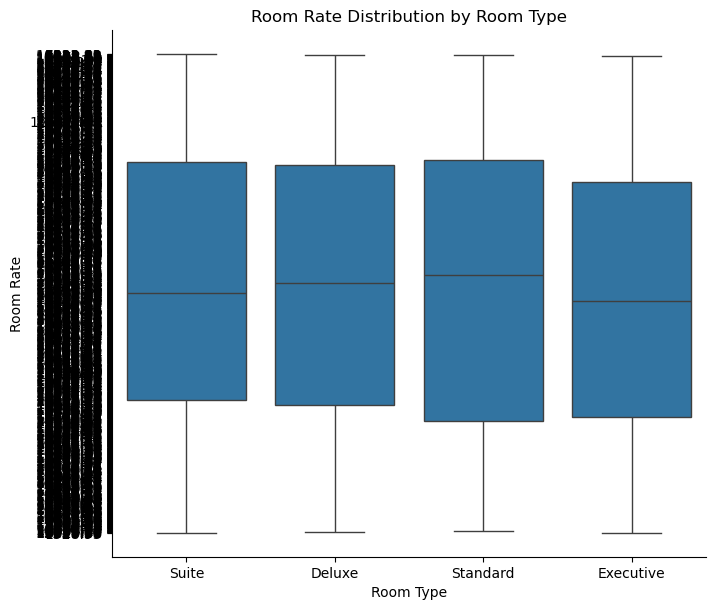

In [8]:
#4. Box Plot of Room Rate by Room Type
#What to plot: Spread and outliers of room rates for each room type
#Columns: Room Type, Room Rate
#Required: Both columns cleaned, Room Rate numeric
#Easy explanation: Helps see which room type is generally expensive and if there are unusual
#high/low prices.

import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=df,
    x="Room Type",
    y="Room Rate",
    kind="box",
    height=6,
    aspect=1.2
)

plt.title("Room Rate Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Room Rate")
plt.show()

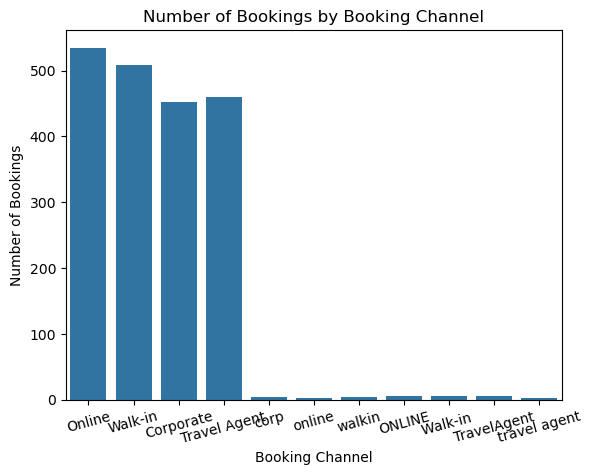

In [9]:
#5.Count Plot of Booking Channel
#What to plot: How many bookings came from each channel
#Columns: Booking Channel
#Required: Channel names standardized (Online, Walk-in, Corporate, Travel Agent)
#Easy explanation: Shows which booking method is most popular.

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="Booking Channel"
)

plt.title("Number of Bookings by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=15)
plt.show()

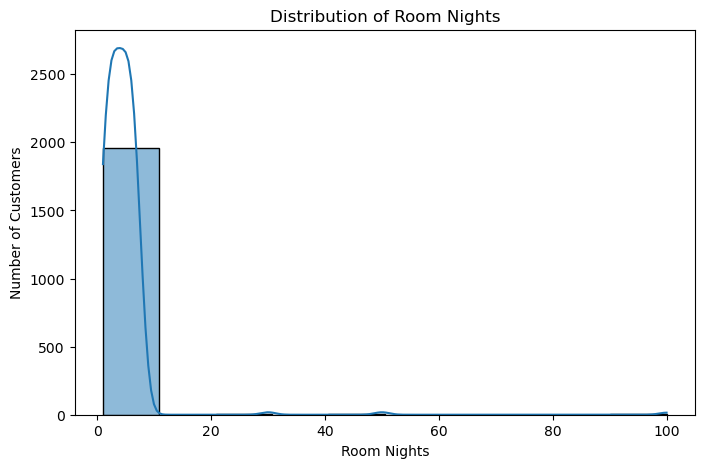

In [13]:
#6.Histogram of Room Nights
#What to plot: How long customers usually stay
#Columns: Room Nights
#Required: Room Nights converted to numbers (remove “3 nights”, “N/A”)
#Easy explanation: Tells whether most people stay 1–2 nights or longer.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Room Nights to numeric
df["Room Nights"] = (
    df["Room Nights"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["Room Nights"] = pd.to_numeric(
    df["Room Nights"],
    errors="coerce"
)

# Create histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Room Nights",
    bins=10,
    kde=True
)

plt.title("Distribution of Room Nights")
plt.xlabel("Room Nights")
plt.ylabel("Number of Customers")
plt.show()

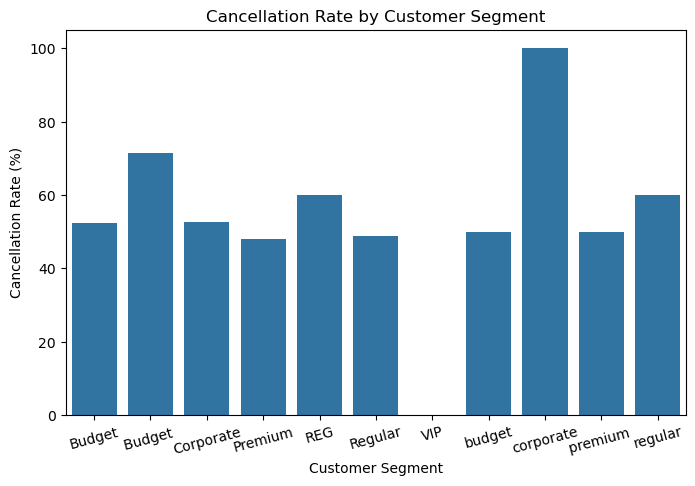

In [14]:
#7.Bar Plot of Cancellation Rate by Customer Segment
#What to plot: Percentage of cancelled bookings in each segment
#Columns: Customer Segment, Cancelled
#Required: Cancelled cleaned to 0/1, Segment standardized
#Easy explanation: Shows which customer group cancels more often.


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clean Cancelled column
df["Cancelled"] = df["Cancelled"].replace({
    "Yes": 1,
    "No": 0,
    "yes": 1,
    "no": 0,
    True: 1,
    False: 0
})

df["Cancelled"] = pd.to_numeric(
    df["Cancelled"],
    errors="coerce"
)

# Calculate cancellation rate by Customer Segment
cancellation_rate = (
    df.groupby("Customer Segment")["Cancelled"]
      .mean()
      .reset_index()
)

# Convert to percentage
cancellation_rate["Cancelled"] = cancellation_rate["Cancelled"] * 100

# Bar plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cancellation_rate,
    x="Customer Segment",
    y="Cancelled"
)

plt.title("Cancellation Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=15)
plt.show()

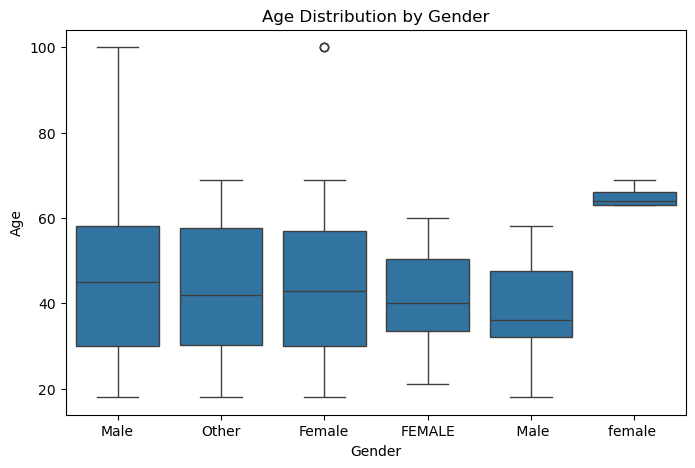

In [15]:
#8.Box Plot of Age by Gender
#What to plot: Age distribution of Male vs Female customers
#Columns: Gender, Age
#Required: Gender standardized (Male/Female/Other), Age numeric
#Easy explanation: Checks if one gender is generally younger or older.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clean Age
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Standardize Gender
df["Gender"] = df["Gender"].replace({
    "male": "Male",
    "Male": "Male",
    "M": "Male",
    "female": "Female",
    "Female": "Female",
    "F": "Female",
    "other": "Other",
    "Other": "Other"
})

# Create box plot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Age"
)

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()    

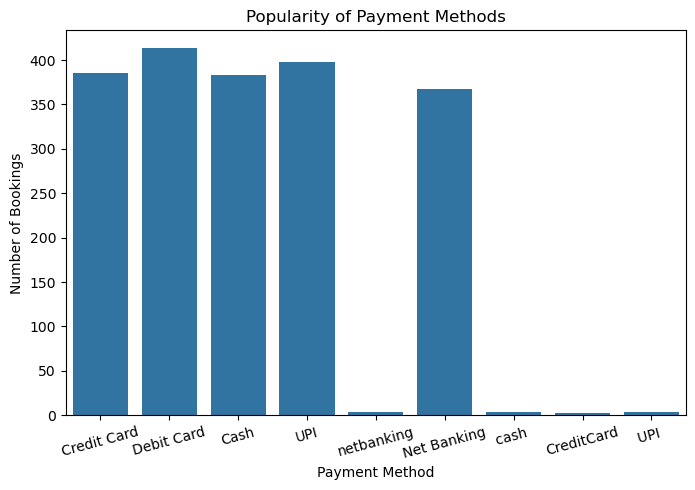

In [16]:
#9.Count Plot of Payment Method
#What to plot: Popularity of different payment methods
#Columns: Payment Method
#Required: Payment Method cleaned and standardized
#Easy explanation: Shows whether Credit Card, UPI, Cash etc. is used more.


import seaborn as sns
import matplotlib.pyplot as plt

# Standardize Payment Method
df["Payment Method"] = df["Payment Method"].replace({
    "credit card": "Credit Card",
    "Credit card": "Credit Card",
    "Credit Card": "Credit Card",
    "upi": "UPI",
    "UPI": "UPI",
    "cash": "Cash",
    "Cash": "Cash"
})

# Count Plot
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Payment Method"
)

plt.title("Popularity of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=15)
plt.show()

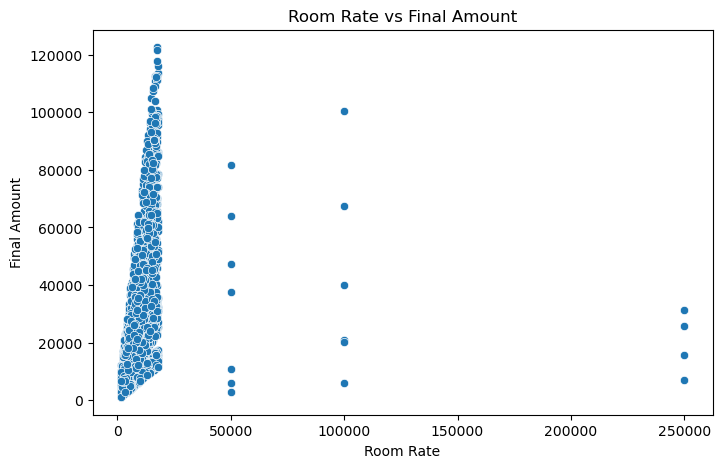

In [17]:
#10.Scatter Plot of Room Rate vs Final Amount
#What to plot: Relationship between room rate and total amount paid
#Columns: Room Rate, Final Amount
#Required: Both columns numeric and cleaned
#Easy explanation: Checks if higher room rates lead to higher final bills.


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert columns to numeric
df["Room Rate"] = pd.to_numeric(
    df["Room Rate"],
    errors="coerce"
)

df["Final Amount"] = pd.to_numeric(
    df["Final Amount"],
    errors="coerce"
)

# Create scatter plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Room Rate",
    y="Final Amount"
)

plt.title("Room Rate vs Final Amount")
plt.xlabel("Room Rate")
plt.ylabel("Final Amount")
plt.show()

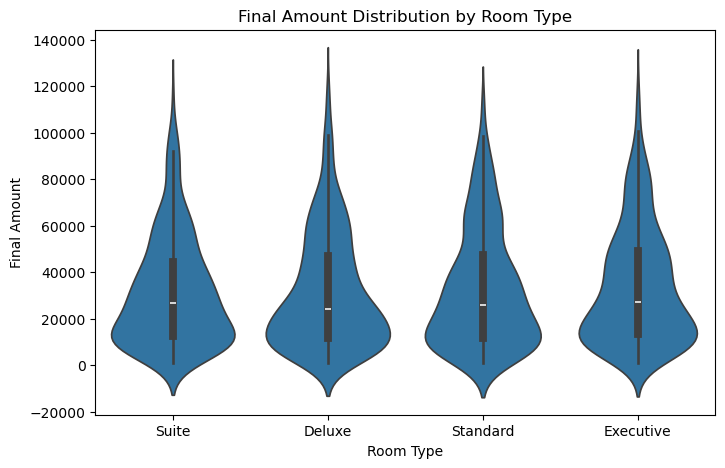

In [18]:
#11.Violin Plot of Final Amount by Room Type
#What to plot: Full distribution of spending for each room type
#Columns: Room Type, Final Amount
#Required: Both columns cleaned
#Easy explanation: Better than box plot – shows the shape of spending (where most values
#lie).

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Final Amount to numeric
df["Final Amount"] = pd.to_numeric(
    df["Final Amount"],
    errors="coerce"
)

# Violin Plot
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Room Type",
    y="Final Amount"
)

plt.title("Final Amount Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Final Amount")
plt.show()

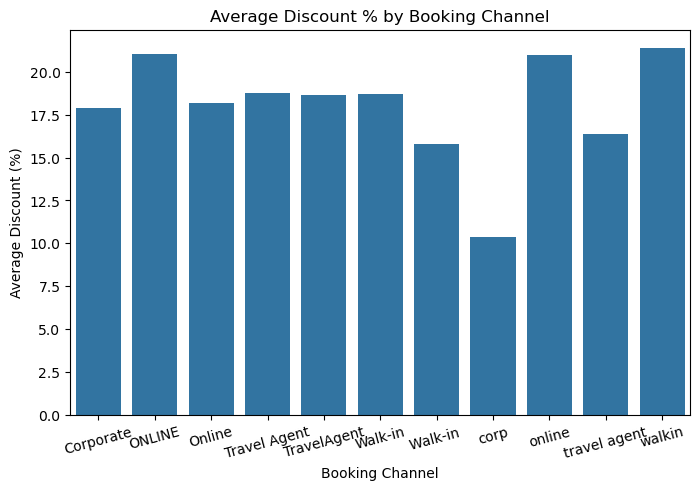

In [19]:
#12.Bar Plot of Average Discount % by Booking Channel
#What to plot: Which channel gives higher average discount
#Columns: Booking Channel, Discount %
#Required: Discount % converted to numbers (0–100)
#Easy explanation: Helps understand discount strategy across channels.


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Discount % to numeric
df["Discount %"] = (
    df["Discount %"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

df["Discount %"] = pd.to_numeric(
    df["Discount %"],
    errors="coerce"
)

# Calculate average discount by booking channel
avg_discount = (
    df.groupby("Booking Channel")["Discount %"]
      .mean()
      .reset_index()
)

# Bar plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_discount,
    x="Booking Channel",
    y="Discount %"
)

plt.title("Average Discount % by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=15)
plt.show()

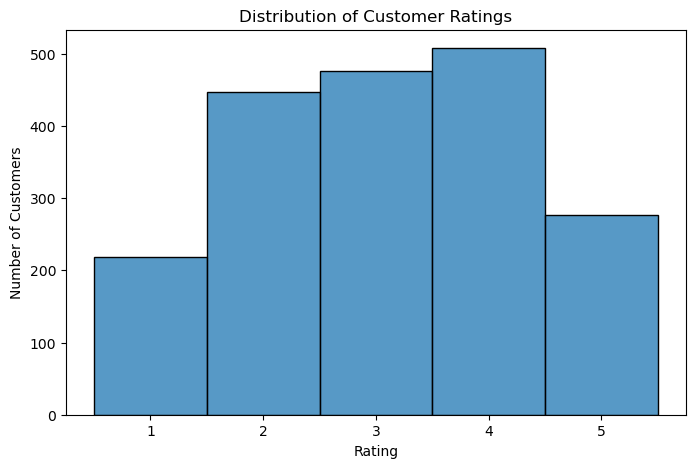

In [20]:
#13.Histogram of Rating
#What to plot: How customers rated their stay
#Columns: Rating
#Required: Rating cleaned (only 1 to 5 values)
#Easy explanation: Shows whether most ratings are high, low, or mixed.


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Rating to numeric
df["Rating"] = pd.to_numeric(
    df["Rating"],
    errors="coerce"
)

# Keep only valid ratings from 1 to 5
df.loc[~df["Rating"].between(1, 5), "Rating"] = pd.NA

# Create histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Rating",
    bins=5,
    discrete=True
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

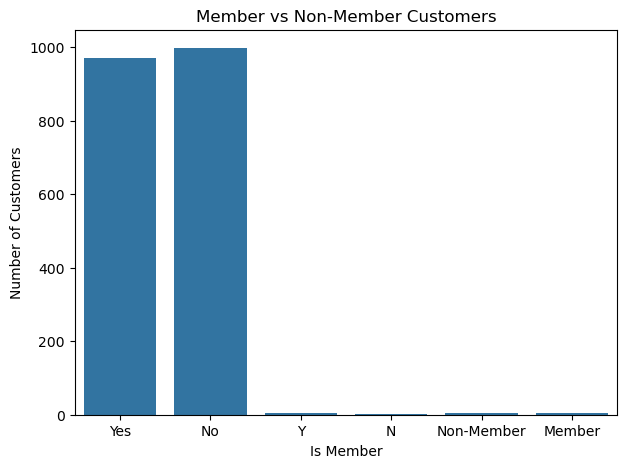

In [21]:
#14.Count Plot of Is Member
#What to plot: How many members vs non-members
#Columns: Is Member
#Required: Converted to Yes/No or 1/0
#Easy explanation: Quick view of member vs non-member ratio.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Standardize Is Member column
df["Is Member"] = df["Is Member"].replace({
    1: "Yes",
    0: "No",
    "1": "Yes",
    "0": "No",
    True: "Yes",
    False: "No",
    "Yes": "Yes",
    "No": "No",
    "yes": "Yes",
    "no": "No"
})

# Count Plot
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Is Member"
)

plt.title("Member vs Non-Member Customers")
plt.xlabel("Is Member")
plt.ylabel("Number of Customers")
plt.show()

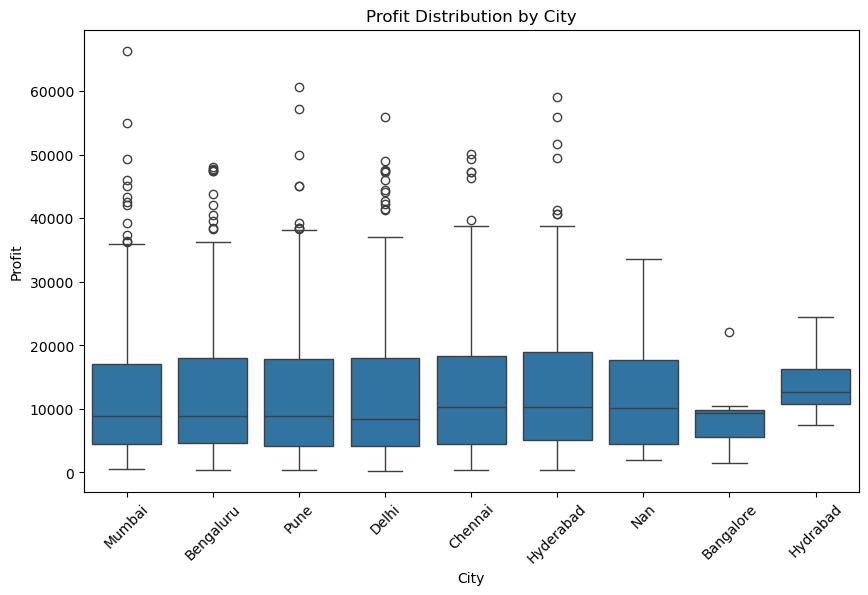

In [22]:
#15.Box Plot of Profit by City
#What to plot: Profit distribution across different cities
#Columns: City, Profit
#Required: City cleaned, Profit numeric
#Easy explanation: Identifies which city is more profitable and if there are extreme
#profits/losses.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Profit to numeric
df["Profit"] = pd.to_numeric(
    df["Profit"],
    errors="coerce"
)

# Clean City names
df["City"] = df["City"].astype(str).str.strip()

# Create box plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="City",
    y="Profit"
)

plt.title("Profit Distribution by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

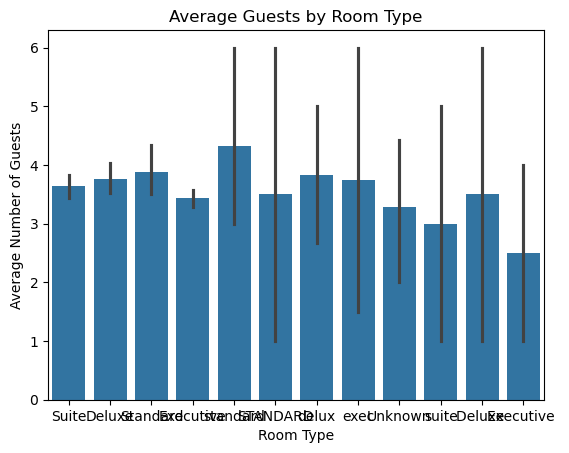

In [9]:
#16. Bar Plot of Average Guests by Room Type
#What to plot: Average number of guests staying in each room type
#Columns: Room Type, Guests
#Required: Both cleaned, Guests numeric
#Easy explanation: Shows whether Suite or Deluxe rooms are used by larger groups.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your hotel dataset
df = pd.read_csv("C:\\Users\\Dell\\Downloads\\Hotel_booking_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert Guests to numeric
df['Guests'] = pd.to_numeric(df['Guests'], errors='coerce')

# Average Guests by Room Type
sns.barplot(
    data=df,
    x='Room Type',
    y='Guests',
    estimator='mean'
)

plt.title('Average Guests by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Number of Guests')
plt.show()

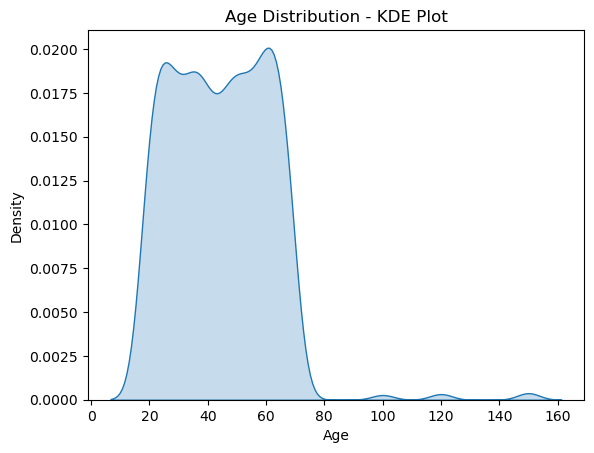

In [10]:
#17. KDE Plot (Density Plot) of Age
#What to plot: Smooth distribution of customer ages
#Columns: Age
#Required: Age numeric and cleaned
#Easy explanation: Similar to histogram but smoother – shows the overall age pattern clearly.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# KDE plot
sns.kdeplot(
    data=df,
    x='Age',
    fill=True
)

plt.title('Age Distribution - KDE Plot')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

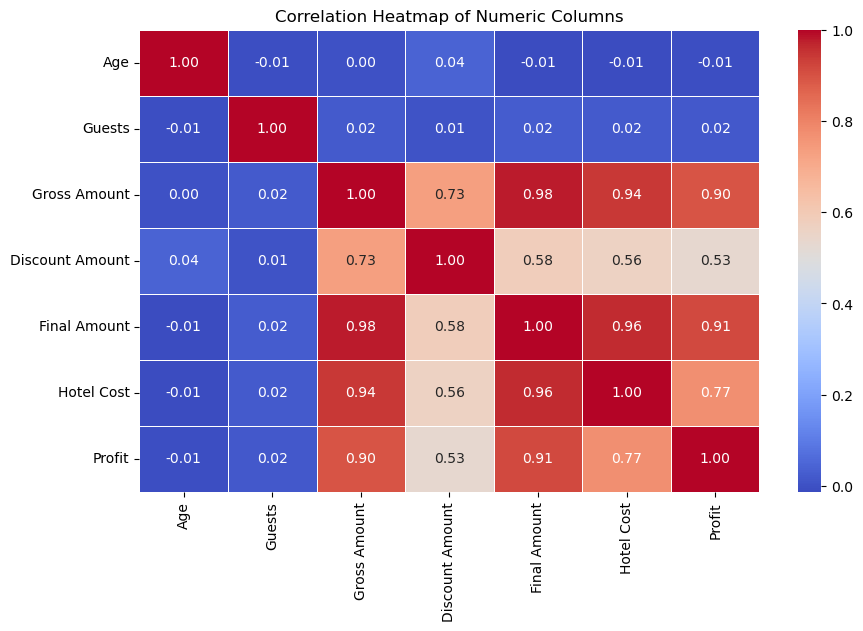

In [11]:
#18. Heatmap of Correlation between Numeric Columns
#What to plot: Relationship strength between numbers like Age, Room Rate, Final Amount,
#Profit, Discount %
#Columns: Select numeric columns only
#Required: All selected columns must be numeric and cleaned
#Easy explanation: Quickly shows which factors move together (positive or negative relation).

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns only
numeric_df = df.select_dtypes(include='number')

# Calculate correlation
corr = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numeric Columns')
plt.show()

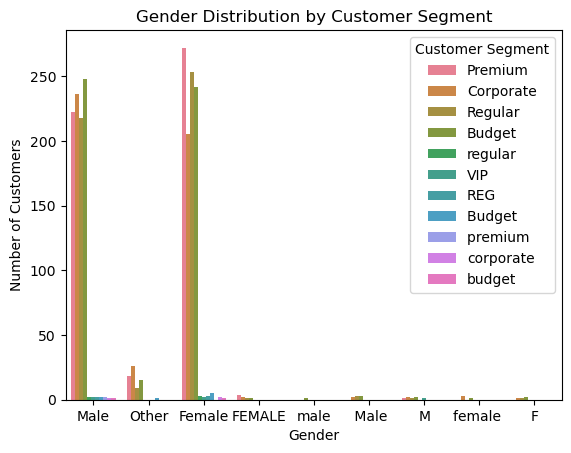

In [12]:
#19.Count Plot of Gender with Hue as Customer Segment
#What to plot: Gender distribution inside each customer segment
#Columns: Gender, Customer Segment
#Required: Both columns cleaned and standardized
#Easy explanation: Shows if Premium segment has more males or females, etc.


import seaborn as sns
import matplotlib.pyplot as plt

# Count Plot
sns.countplot(
    data=df,
    x='Gender',
    hue='Customer Segment'
)

plt.title('Gender Distribution by Customer Segment')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

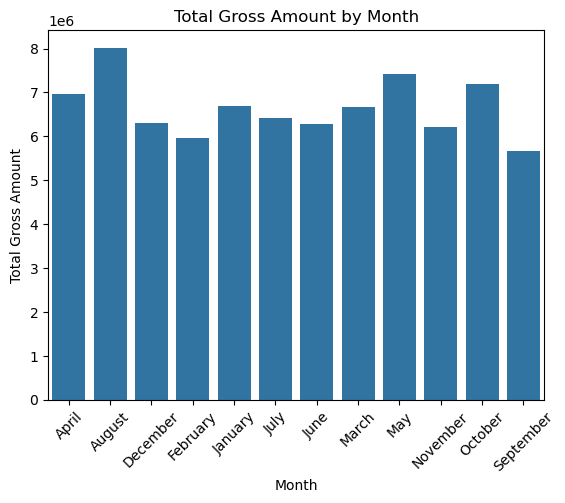

In [13]:
#20. Bar Plot of Total Gross Amount by Month (from Booking Date)
#What to plot: Total revenue generated in each month
#Columns: Booking Date, Gross Amount
#Required: Booking Date converted to proper date format, then extract month
#Easy explanation: Shows which months are busiest in terms of revenue.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Booking Date to datetime
df['Booking Date'] = pd.to_datetime(df['Booking Date'], errors='coerce')

# Convert Gross Amount to numeric
df['Gross Amount'] = pd.to_numeric(df['Gross Amount'], errors='coerce')

# Extract month
df['Month'] = df['Booking Date'].dt.month_name()

# Calculate total Gross Amount by month
monthly_revenue = df.groupby('Month')['Gross Amount'].sum().reset_index()

# Create bar plot
sns.barplot(
    data=monthly_revenue,
    x='Month',
    y='Gross Amount'
)

plt.title('Total Gross Amount by Month')
plt.xlabel('Month')
plt.ylabel('Total Gross Amount')
plt.xticks(rotation=45)
plt.show()